24BAD010-Anusri T
RMSE : 0.12441068945308187
MAE: 0.0796986807866371
      movieId                                              title  \
302       344                  Ace Ventura: Pet Detective (1994)   
474       541                                Blade Runner (1982)   
2110     2804                          Christmas Story, A (1983)   
3638     4993  Lord of the Rings: The Fellowship of the Ring,...   
4137     5952      Lord of the Rings: The Two Towers, The (2002)   

                      genres  
302                   Comedy  
474   Action|Sci-Fi|Thriller  
2110         Children|Comedy  
3638       Adventure|Fantasy  
4137       Adventure|Fantasy  


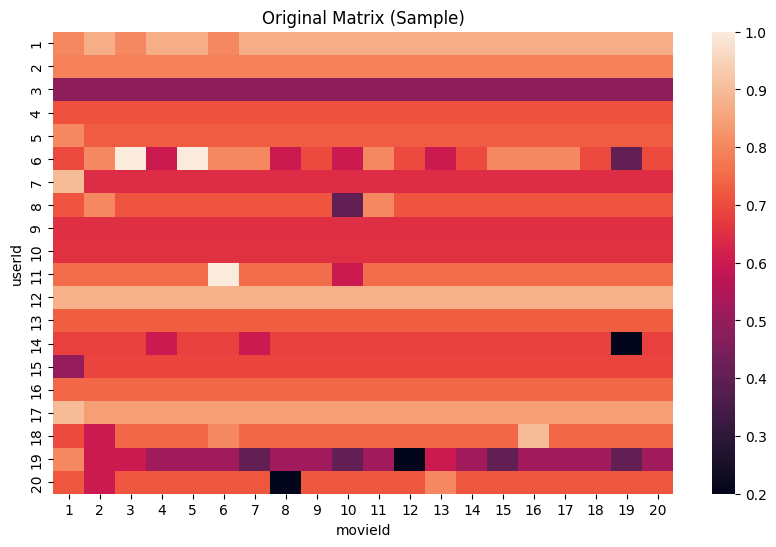

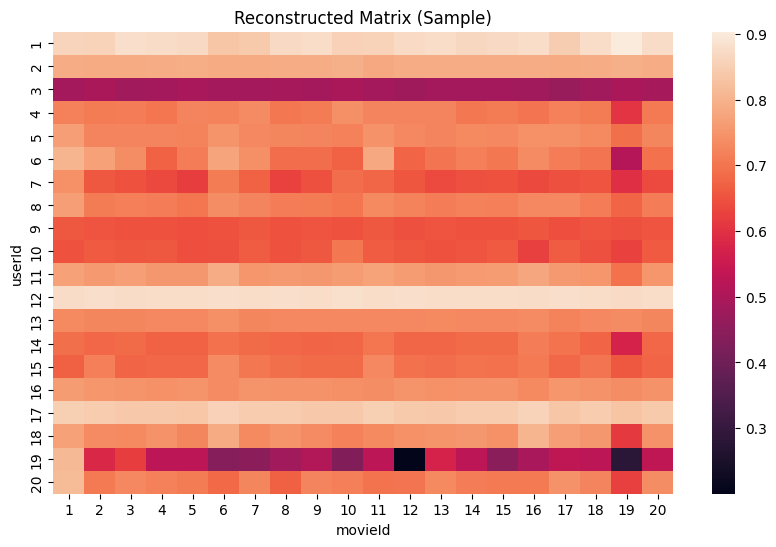

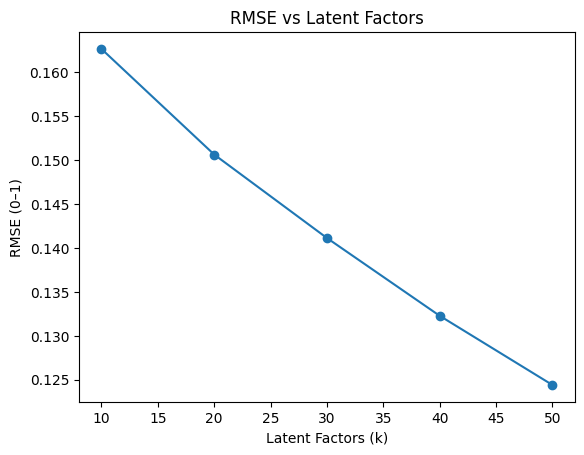

In [1]:
print("24BAD010-Anusri T")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.sparse.linalg import svds

ratings = pd.read_csv(r"C:\Users\anusr\Downloads\ratings.csv (1)\ratings.csv")
movies = pd.read_csv(r"C:\Users\anusr\Downloads\movies (1).csv")

ratings['rating'] = ratings['rating'] / 5.0

df = pd.merge(ratings, movies, on='movieId')

user_item_matrix = df.pivot_table(index='userId', columns='movieId', values='rating')

user_item_matrix_filled = user_item_matrix.apply(lambda row: row.fillna(row.mean()), axis=1)

R = user_item_matrix_filled.values

user_ratings_mean = np.mean(R, axis=1)
R_demeaned = R - user_ratings_mean.reshape(-1, 1)

train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42)

k = 50
U, sigma, Vt = svds(R_demeaned, k=k)

sigma = np.diag(sigma)

R_pred = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)
R_pred = np.clip(R_pred, 0, 1)

pred_df = pd.DataFrame(R_pred, columns=user_item_matrix.columns, index=user_item_matrix.index)

y_true = []
y_pred = []

for row in test_data.itertuples():
    try:
        pred = pred_df.loc[row.userId, row.movieId]
        y_true.append(row.rating)
        y_pred.append(pred)
    except:
        continue

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print("RMSE :", rmse)
print("MAE:", mae)

def recommend_movies(user_id, num_recommendations=10):
    user_row = pred_df.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index
    recommendations = user_row.drop(already_rated)
    top_movies = recommendations.sort_values(ascending=False).head(num_recommendations)
    return movies[movies['movieId'].isin(top_movies.index)]

print(recommend_movies(user_id=1, num_recommendations=5))

plt.figure(figsize=(10, 6))
sns.heatmap(user_item_matrix_filled.iloc[:20, :20], cmap='rocket')
plt.title("Original Matrix (Sample)")
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(pred_df.iloc[:20, :20], cmap='rocket')
plt.title("Reconstructed Matrix (Sample)")
plt.show()

k_values = [10, 20, 30, 40, 50]
rmse_list = []

for k in k_values:
    U, sigma, Vt = svds(R_demeaned, k=k)
    sigma = np.diag(sigma)

    R_pred_temp = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)
    R_pred_temp = np.clip(R_pred_temp, 0, 1)

    pred_df_temp = pd.DataFrame(R_pred_temp, columns=user_item_matrix.columns, index=user_item_matrix.index)

    y_pred_temp = []
    y_true_temp = []

    for row in test_data.itertuples():
        try:
            pred = pred_df_temp.loc[row.userId, row.movieId]
            y_true_temp.append(row.rating)
            y_pred_temp.append(pred)
        except:
            continue

    rmse_temp = np.sqrt(mean_squared_error(y_true_temp, y_pred_temp))
    rmse_list.append(rmse_temp)

plt.figure()
plt.plot(k_values, rmse_list, marker='o')
plt.xlabel("Latent Factors (k)")
plt.ylabel("RMSE (0–1)")
plt.title("RMSE vs Latent Factors")
plt.show()

24BAD010-Anusri T
RMSE: 0.49088883050563653
Precision@10: 0.5504918032786885
Recall@10: 0.11735351018323487
      movieId                                   title  \
507       589       Terminator 2: Judgment Day (1991)   
793      1036                         Die Hard (1988)   
902      1200                           Aliens (1986)   
1057     1374  Star Trek II: The Wrath of Khan (1982)   
2078     2762                 Sixth Sense, The (1999)   

                                genres  
507                      Action|Sci-Fi  
793              Action|Crime|Thriller  
902     Action|Adventure|Horror|Sci-Fi  
1057  Action|Adventure|Sci-Fi|Thriller  
2078              Drama|Horror|Mystery  


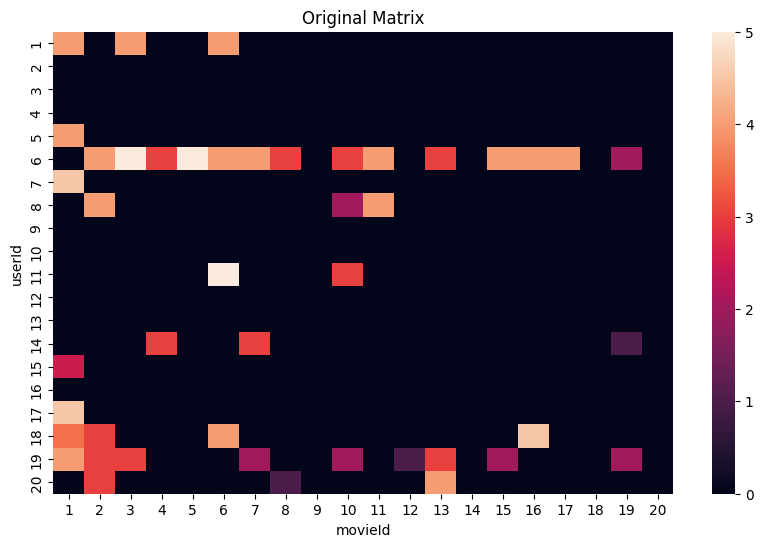

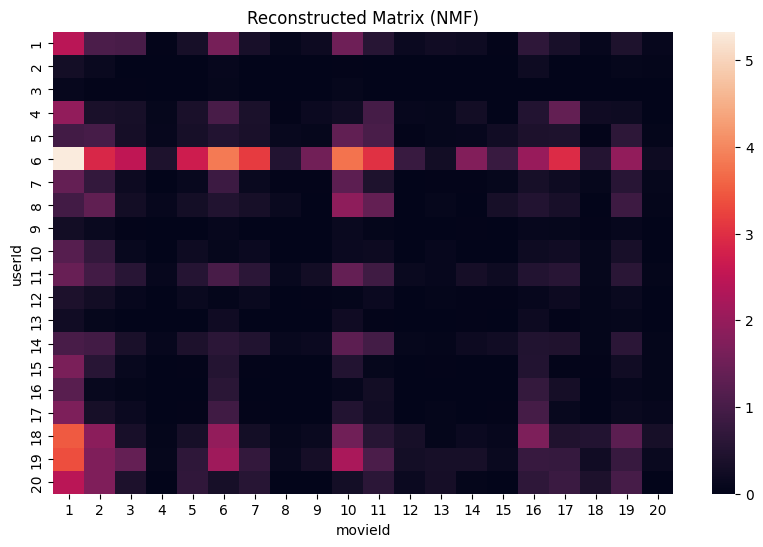

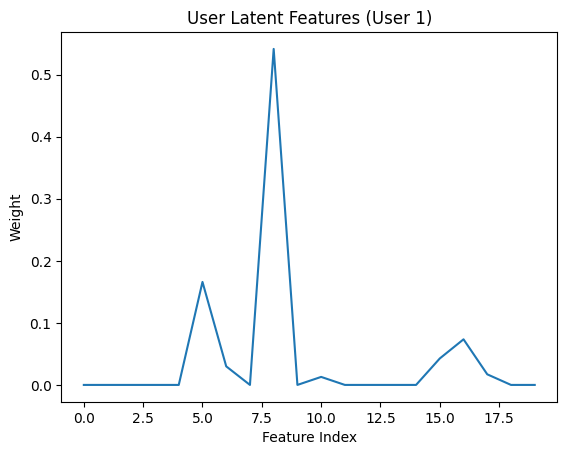

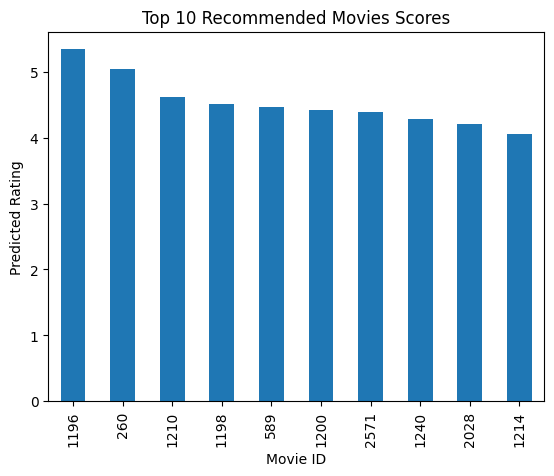

In [3]:
print("24BAD010-Anusri T")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

ratings = pd.read_csv(r"C:\Users\anusr\Downloads\ratings.csv (1)\ratings.csv")
movies = pd.read_csv(r"C:\Users\anusr\Downloads\movies (1).csv")

user_item_matrix = ratings.pivot_table(index='userId', columns='movieId', values='rating')
user_item_filled = user_item_matrix.fillna(0)

R = user_item_filled.values

k = 20

nmf_model = NMF(n_components=k, init='random', random_state=42, max_iter=200)

W = nmf_model.fit_transform(R)
H = nmf_model.components_

R_pred = np.dot(W, H)

pred_df = pd.DataFrame(R_pred, columns=user_item_matrix.columns, index=user_item_matrix.index)

def predict_rating(user, movie):
    return pred_df.loc[user, movie]

train, test = train_test_split(ratings, test_size=0.2, random_state=42)

y_true = []
y_pred = []

for row in test.itertuples():
    try:
        if row.userId in pred_df.index and row.movieId in pred_df.columns:
            pred = pred_df.loc[row.userId, row.movieId]

            if pred < 0:
                pred = 0
            elif pred > 5:
                pred = 5

            y_true.append(row.rating)
            y_pred.append(pred)
    except:
        continue

rmse = np.sqrt(mean_squared_error(y_true, y_pred)) / 5
print("RMSE:", rmse)

def precision_recall_at_k(pred_df, original_df, k=10, threshold=3.5):
    precisions = []
    recalls = []

    for user in pred_df.index:
        pred_ratings = pred_df.loc[user].sort_values(ascending=False)
        top_k = pred_ratings.head(k).index

        actual_ratings = original_df.loc[user].dropna()
        relevant = actual_ratings[actual_ratings >= threshold].index

        recommended_relevant = set(top_k).intersection(set(relevant))

        precision = len(recommended_relevant) / k if k > 0 else 0
        recall = len(recommended_relevant) / len(relevant) if len(relevant) > 0 else 0

        precisions.append(precision)
        recalls.append(recall)

    return np.mean(precisions), np.mean(recalls)

precision, recall = precision_recall_at_k(pred_df, user_item_matrix, k=10)

print("Precision@10:", precision)
print("Recall@10:", recall)

def recommend_movies(user_id, num_recommendations=10):
    user_ratings = user_item_matrix.loc[user_id]
    already_rated = user_ratings.dropna().index

    recommendations = pred_df.loc[user_id].drop(already_rated)
    top_movies = recommendations.sort_values(ascending=False).head(num_recommendations)

    return movies[movies['movieId'].isin(top_movies.index)]

print(recommend_movies(user_id=1, num_recommendations=5))

plt.figure(figsize=(10, 6))
sns.heatmap(user_item_filled.iloc[:20, :20])
plt.title("Original Matrix")
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(pred_df.iloc[:20, :20])
plt.title("Reconstructed Matrix (NMF)")
plt.show()

plt.figure()
plt.plot(W[0])
plt.title("User Latent Features (User 1)")
plt.xlabel("Feature Index")
plt.ylabel("Weight")
plt.show()

user_id = 1
recommended = pred_df.loc[user_id].sort_values(ascending=False).head(10)

plt.figure()
recommended.plot(kind='bar')
plt.title("Top 10 Recommended Movies Scores")
plt.xlabel("Movie ID")
plt.ylabel("Predicted Rating")
plt.show()